### Importa los datos
Dataset con diferentes fármacos, sus efectos y ratings de los clientes.

Importa el dataset *drugLibTrain_raw.tsv*

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')



df = pd.read_csv('data/drugLibTrain_raw.tsv', sep='\t')
# el archivo es .tsv, que son datos separados por tabulaciones, asíq ue pongo sep='\t'




print('Shape:', df.shape)
df.head()

Shape: (3107, 9)


,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above


### Descriptive Analysis

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3107 entries, 0 to 3106
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         3107 non-null   int64 
 1   urlDrugName        3107 non-null   object
 2   rating             3107 non-null   int64 
 3   effectiveness      3107 non-null   object
 4   sideEffects        3107 non-null   object
 5   condition          3106 non-null   object
 6   benefitsReview     3089 non-null   object
 7   sideEffectsReview  3032 non-null   object
 8   commentsReview     3095 non-null   object
dtypes: int64(2), object(7)
memory usage: 218.6+ KB


In [5]:
df.describe()

# muestra las únicas dos columnas numñericas de df

# hay 4162 filas en el archivo original, min 0 máx 4161
# df train tiene 3107 de ellas
# el resto imagino que estaránen un test

# valoración media del paciente es un 7 sobre 10
# notas se dispersan bastante, casi 3 puntos arriba o abajo de la media
# 25% pacientes dio un 5 o menos
# mediana ye 8, 50% pacietnes dio un 8 o más
# 75% pacientes dio un 9 o menos

# la media ye menor que la mediana
# sigfca distribución está sesgada hacia la izquierda, la mayoría de pacientes puntúa alto, de ahí la mediana en 8
# luego minoría que puntúa muy bajo (1-3), y esos valores bajos "tiran" de la media hacia abajo hasta el 7

# real life: la gente que está satisfecha con su fármaco tiende a puntuar alto, pero hay casos donde el medicamento
# no funcionó o tuvo efectos secundarios graves, y esos pacientes puntúan muy bajo

,Unnamed: 0,rating
count,3107.000000,3107.000000
mean,2080.607016,7.006115
std,1187.998828,2.937582
min,0.000000,1.000000
25%,1062.500000,5.000000
50%,2092.000000,8.000000
75%,3092.500000,9.000000
max,4161.000000,10.000000


Quedate únicamente con las columnas que podamos manejar: Columnas numéricas y columnas categóricas con pocas categorías (menos de 10)

In [ ]:
# separo cols numéricas, menos el índice 'Unnamed: 0', que no aporta
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if 'Unnamed' not in c]
print(num_cols)

# cols categóricas con menos de 10 categorías únicas
categ_cols = df.select_dtypes(include=['object']).columns.tolist()
categ_ok = [col for col in categ_cols if df[col].nunique() < 10]
print(categ_ok)

for col in categ_ok:
    print(f'{col} ({df[col].nunique()} categorcas): {df[col].unique()}')
    
    
    
# para k-means descarto lo que no puedo usar como reseñas escritas por paciente etc
# me quedo con: rating, effectiveness y sideEffects

['rating']
['effectiveness', 'sideEffects']
effectiveness (5 categorcas): ['Highly Effective' 'Marginally Effective' 'Ineffective'
 'Considerably Effective' 'Moderately Effective']
sideEffects (5 categorcas): ['Mild Side Effects' 'Severe Side Effects' 'No Side Effects'
 'Extremely Severe Side Effects' 'Moderate Side Effects']


In [ ]:
# me qeudo sólo con las cols que peudo manejar
cols_si = num_cols + categ_ok
df_kmeans = df[cols_si].dropna().copy() 
# creo nuevo df con solo las 3 columnas que me interesan
# de paso elimino cualquier fila que tenga algún valor vacío con el dropna()

cols_si

['rating', 'effectiveness', 'sideEffects']

In [8]:
df_kmeans.shape

(3107, 3)

In [9]:
df_kmeans.head()

,rating,effectiveness,sideEffects
0,4,Highly Effective,Mild Side Effects
1,1,Highly Effective,Severe Side Effects
2,10,Highly Effective,No Side Effects
3,3,Marginally Effective,Mild Side Effects
4,2,Marginally Effective,Severe Side Effects


#### Transforma las columnas categóricas

Transforma las columnas categoricas a numericas mediante dummies

In [10]:
df_kmeans['effectiveness'].value_counts()

effectiveness
Highly Effective          1330
Considerably Effective     928
Moderately Effective       415
Ineffective                247
Marginally Effective       187
Name: count, dtype: int64

In [11]:
df_kmeans['sideEffects'].value_counts()

sideEffects
Mild Side Effects                1019
No Side Effects                   930
Moderate Side Effects             614
Severe Side Effects               369
Extremely Severe Side Effects     175
Name: count, dtype: int64

In [ ]:
df_encoded = pd.get_dummies(df_kmeans, columns=categ_ok, drop_first=True) # meto drop_first para evitar redundancias
 
df_encoded.head()

,rating,effectiveness_Highly Effective,effectiveness_Ineffective,effectiveness_Marginally Effective,effectiveness_Moderately Effective,sideEffects_Mild Side Effects,sideEffects_Moderate Side Effects,sideEffects_No Side Effects,sideEffects_Severe Side Effects
0,4,True,False,False,False,True,False,False,False
1,1,True,False,False,False,False,False,False,True
2,10,True,False,False,False,False,False,True,False
3,3,False,False,True,False,True,False,False,False
4,2,False,False,True,False,False,False,False,True


In [13]:
df_encoded.shape

(3107, 9)

In [14]:
df_encoded.columns.tolist()

['rating',
 'effectiveness_Highly Effective',
 'effectiveness_Ineffective',
 'effectiveness_Marginally Effective',
 'effectiveness_Moderately Effective',
 'sideEffects_Mild Side Effects',
 'sideEffects_Moderate Side Effects',
 'sideEffects_No Side Effects',
 'sideEffects_Severe Side Effects']

In [ ]:
from sklearn.preprocessing import StandardScaler

# como k-means es sensible a la escala de las variables, voy escalar los datos
scaler = StandardScaler()
X = scaler.fit_transform(df_encoded)

X.shape

# ene ste caso tengo 'rating' con valores del 1 al 10 y las dummies con valores de 0 a 1
# k-means calcula distancias entre puntos, y si una variable tiene números mucho más grandes que otra,
# esa variable domina el resultado "injustamente"

# pequeño recordatorio pa mi:
# standardscaler lo iguala, transforma todas las variables para que tengan media 0 y desviación estándar 1
# así todas las variables pesan igual


(3107, 9)

#### Evalua cual es la mejor K

Utiliza silhouette_score para evaluar cual es la mejor K.

In [ ]:
# silhouette score mide qué tan bien está clasificado cada punto
# cercano a 1: punto está bien dentro de su cluster y lejos de los demás
# cercano a 0: punto está en la frontera entre clusters
# cercano a -1: punto probably está en el wrong cluster

In [71]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# voy probar dos k y quiero almacenar la silhouette score e inercia en una lista para luego
# así puedo utilizarlos más ademante sin volver a entrenarlos
# útil para comparar centroides, etiquetas, métricas o visualizaciones entre diferentes valores de KeyError

silhouette_scores = []
inertias = []
kmeans_per_k = []
k_values = []


In [72]:
k=2

kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
kmeans.fit(X)

score = silhouette_score(X, kmeans.labels_)

silhouette_scores.append(score)
inertias.append(kmeans.inertia_)
kmeans_per_k.append(kmeans)
k_values.append(k)


print(f'para K={k}, la silhouette score ye de {score:.4f} y lainertia de {kmeans.inertia_:.2f}')

para K=2, la silhouette score ye de 0.2859 y lainertia de 22215.85


In [73]:
k=4

kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
kmeans.fit(X)

score = silhouette_score(X, kmeans.labels_)
silhouette_scores.append(score)

inertias.append(kmeans.inertia_)
kmeans_per_k.append(kmeans)
k_values.append(k)

print(f'para K={k}, la silhouette score ye de {score:.4f} y lainertia de {kmeans.inertia_:.2f}')

para K=4, la silhouette score ye de 0.4088 y lainertia de 14548.43


In [74]:
k=6

kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
kmeans.fit(X)

score = silhouette_score(X, kmeans.labels_)
silhouette_scores.append(score)

inertias.append(kmeans.inertia_)
kmeans_per_k.append(kmeans)
k_values.append(k)

print(f'para K={k}, la silhouette score ye de {score:.4f} y lainertia de {kmeans.inertia_:.2f}')

para K=6, la silhouette score ye de 0.5118 y lainertia de 8869.94


In [75]:
k=8

kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
kmeans.fit(X)

score = silhouette_score(X, kmeans.labels_)
silhouette_scores.append(score)

inertias.append(kmeans.inertia_)
kmeans_per_k.append(kmeans)
k_values.append(k)

print(f'para K={k}, la silhouette score ye de {score:.4f} y lainertia de {kmeans.inertia_:.2f}')

para K=8, la silhouette score ye de 0.5757 y lainertia de 6154.45


In [76]:
k=10

kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
kmeans.fit(X)

score = silhouette_score(X, kmeans.labels_)
silhouette_scores.append(score)

inertias.append(kmeans.inertia_)
kmeans_per_k.append(kmeans)
k_values.append(k)

print(f'para K={k}, la silhouette score ye de {score:.4f} y lainertia de {kmeans.inertia_:.2f}')

para K=10, la silhouette score ye de 0.6603 y lainertia de 4622.91


In [77]:
silhouette_scores

[0.2859404855465951,
 0.40882690975511293,
 0.5118143915125224,
 0.5757450453905016,
 0.660300904060985]

In [78]:
inertias

[22215.851594108688,
 14548.432403544637,
 8869.936687707146,
 6154.451154244237,
 4622.910742651751]

In [79]:
kmeans_per_k

[KMeans(n_clusters=2, n_init=10, random_state=42),
 KMeans(n_clusters=4, n_init=10, random_state=42),
 KMeans(n_clusters=6, n_init=10, random_state=42),
 KMeans(n_init=10, random_state=42),
 KMeans(n_clusters=10, n_init=10, random_state=42)]

In [ ]:
best_k_idx = silhouette_scores.index(max(silhouette_scores))
best_k_idx 

# el 4 es el índice del mejor k

4

In [81]:
best_k = k_values[best_k_idx]
best_k

# el mejor k es 10

10

In [82]:
k_values

[2, 4, 6, 8, 10]

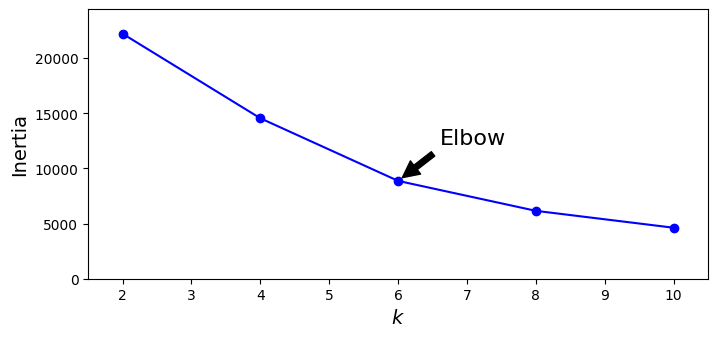

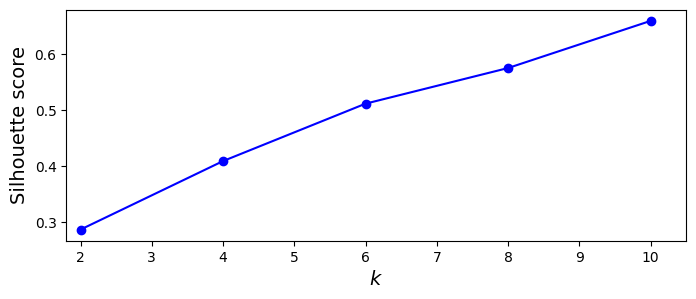

In [ ]:
# LO DEL CODITO
plt.figure(figsize=(8, 3.5))
plt.plot(k_values, inertias, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inertia", fontsize=14)

elbow_k = 6 # señaloel elbow en k=6, x ejemplo
elbow_idx = k_values.index(elbow_k)

plt.annotate('Elbow',
             xy=(elbow_k, inertias[elbow_idx]),
             xytext=(0.55, 0.55),
             textcoords='figure fraction',
             fontsize=16,
             arrowprops=dict(facecolor='black', shrink=0.1)
            )

plt.axis([min(k_values)-0.5, max(k_values)+0.5, 0, max(inertias)*1.1])
plt.show()


# SILHOUETTE SCORE
plt.figure(figsize=(8, 3))
plt.plot(k_values, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)

plt.axis([min(k_values)-0.2, max(k_values)+0.5,
          min(silhouette_scores)-0.02,
          max(silhouette_scores)+0.02])

plt.show()


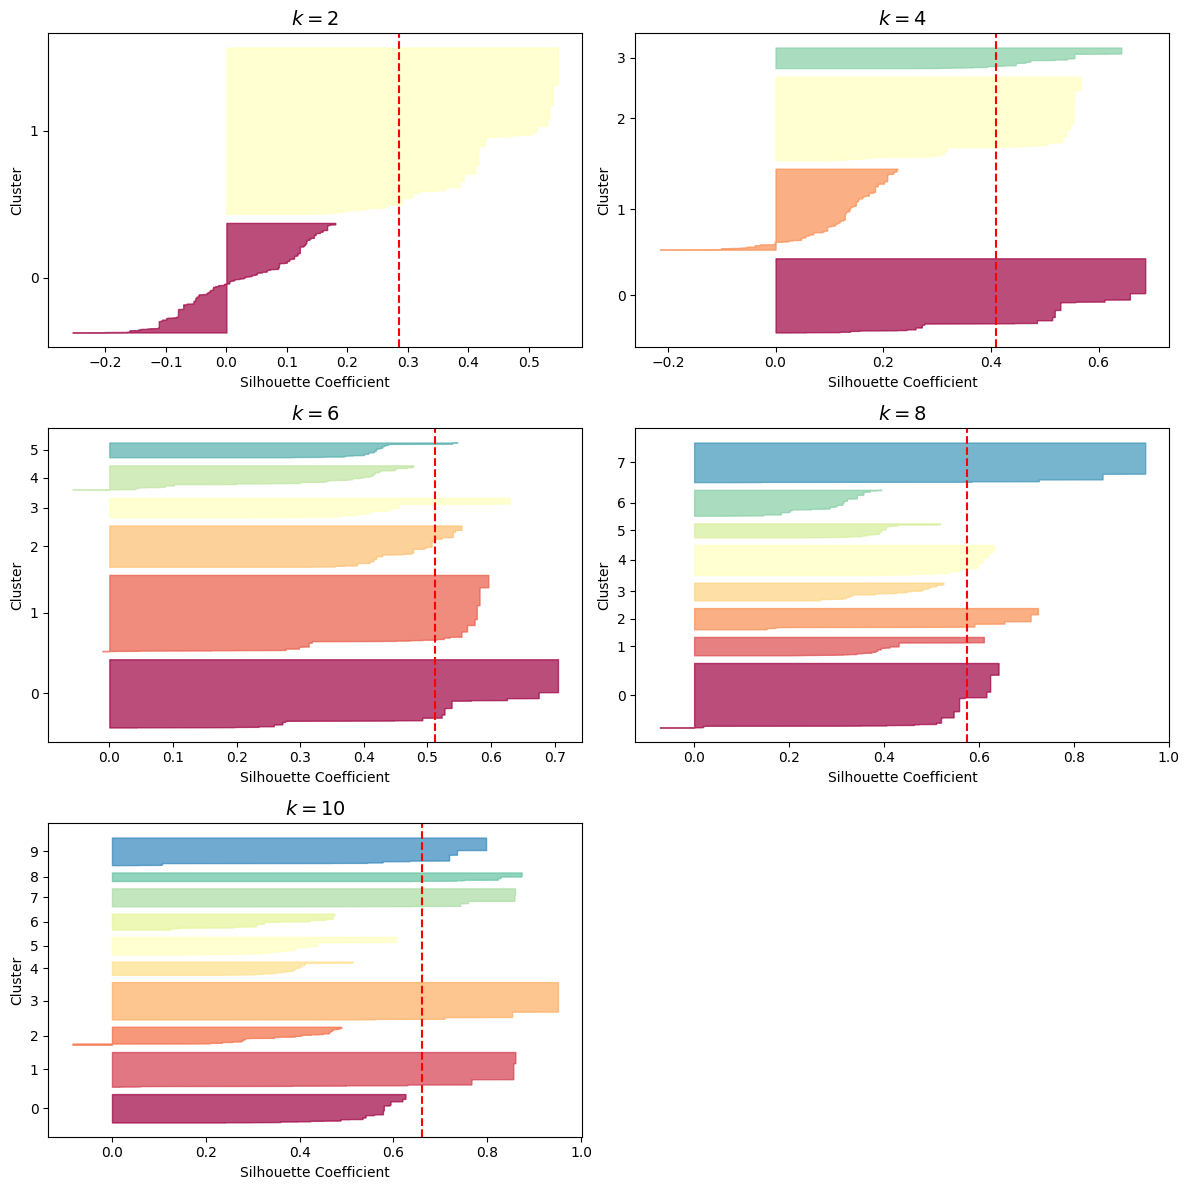

In [ ]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import math

Ks = k_values

n = len(Ks)
cols = 2
rows = math.ceil(n / cols)

plt.figure(figsize=(12, rows * 4))

for idx, k in enumerate(Ks):
    plt.subplot(rows, cols, idx + 1)

    kmeans = kmeans_per_k[idx]
    y_pred = kmeans.labels_
    silhouette_coeffs = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []

    for cluster_id in range(k):
        coeffs = silhouette_coeffs[y_pred == cluster_id]
        coeffs.sort()

        color = mpl.cm.Spectral(cluster_id / k)
        plt.fill_betweenx(
            np.arange(pos, pos + len(coeffs)),
            0, coeffs,
            facecolor=color,
            edgecolor=color,
            alpha=0.7
        )

        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))

    plt.xlabel("Silhouette Coefficient")
    plt.ylabel("Cluster")

    plt.axvline(
        x=silhouette_scores[idx],
        color="red",
        linestyle="--",
        linewidth=1.5
    )

    plt.title(f"$k={k}$", fontsize=14)

plt.tight_layout()
plt.show()

#### Genera el K Means 

In [ ]:
# entreno el modelo final con la mejor K
kmeans_final = KMeans(n_clusters=best_k,
                      n_init=10, # 10 puntos de inicio distintos y se queda con el mejor resultado
                      random_state=42)

kmeans_final.fit(X) # sonla s etiquetas asignadas a cada fila: un número de 0 a 9 que dice a qué cluster pertenece cada paciente

# añado la etiqueta de cluster al df original
df_kmeans['cluster'] = kmeans_final.labels_

print(f'Modelo entrenado con K = {best_k}')
print(f'Inercia final: {kmeans_final.inertia_:.2f}')
print(f'Silhouette Score final: {silhouette_score(X, kmeans_final.labels_):.4f}')

Modelo entrenado con K = 10
Inercia final: 4622.91
Silhouette Score final: 0.6603


Comprueba los resultados y muestra en un pie plot la distribución de los distintos clusters.

In [ ]:
# ahora voy mostrar la distribución de instancias por cluster
cluster_counts = df_kmeans['cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    pct = count / len(df_kmeans) * 100
    print(f'cluster {cluster_id}: {count:4d} muestras ({pct:.1f}%)')

# ahora la media de las variables num por cluster
print(df_kmeans.groupby('cluster')[num_cols].mean().round(2))

# cuento cuántos pacientes cayeron en cada grupo y calculp el rating medio de cada cluster
# así puedo coscarme si los grupos tienen sentido o están muy descompensados

cluster 0:  403 muestras (13.0%)
cluster 1:  492 muestras (15.8%)
cluster 2:  255 muestras (8.2%)
cluster 3:  529 muestras (17.0%)
cluster 4:  187 muestras (6.0%)
cluster 5:  247 muestras (7.9%)
cluster 6:  226 muestras (7.3%)
cluster 7:  255 muestras (8.2%)
cluster 8:  122 muestras (3.9%)
cluster 9:  391 muestras (12.6%)
         rating
cluster        
0          7.25
1          9.11
2          4.24
3          9.70
4          3.40
5          1.56
6          5.98
7          8.46
8          5.45
9          7.58


In [ ]:
# análisis categórico por cluster

# moda de effectiveness por cluster:
print(df_kmeans.groupby('cluster')['effectiveness'].agg(lambda x: x.value_counts().index[0]))

# moda de sideeffects por cluster:
print(df_kmeans.groupby('cluster')['sideEffects'].agg(lambda x: x.value_counts().index[0]))


# para cada cluster, calculamos cuál es la efectividad y los efectos secundarios más frecuentes (la moda)
# es como preguntar: "de todos los pacientes de este grupo, ¿cuál es la respuesta más repetida?"
# esto nos permite ponerle nombre o descripción a cada cluster, por ejemplo: "cluster 3: fármacos muy
# efectivos con efectos secundarios leves"


cluster
0          Highly Effective
1          Highly Effective
2          Highly Effective
3          Highly Effective
4      Marginally Effective
5               Ineffective
6      Moderately Effective
7    Considerably Effective
8      Moderately Effective
9    Considerably Effective
Name: effectiveness, dtype: object
cluster
0    Moderate Side Effects
1        Mild Side Effects
2      Severe Side Effects
3          No Side Effects
4      Severe Side Effects
5      Severe Side Effects
6        Mild Side Effects
7          No Side Effects
8    Moderate Side Effects
9        Mild Side Effects
Name: sideEffects, dtype: object


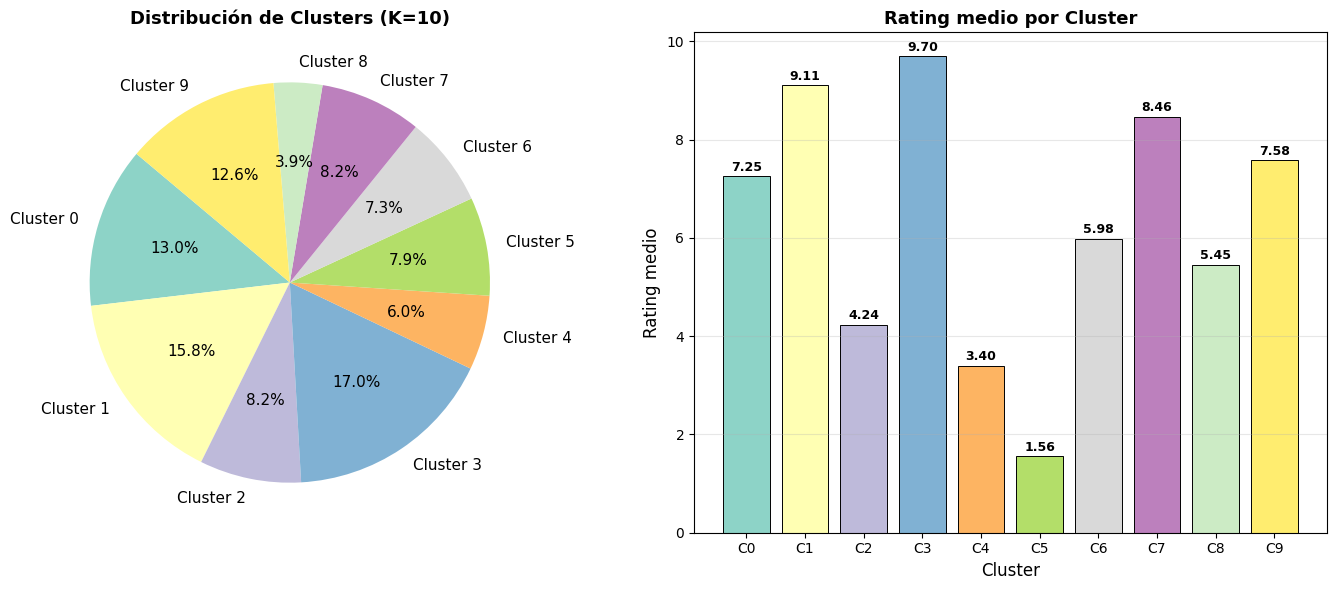

In [96]:
# pie plot de distribución de clusters

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# pie chart
labels = [f'Cluster {i}' for i in cluster_counts.index]
colors = plt.cm.Set3(np.linspace(0, 1, best_k))

axes[0].pie(
    cluster_counts.values,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 11}
)
axes[0].set_title(f'Distribución de Clusters (K={best_k})', fontsize=13, fontweight='bold')

# Bar chart con media de rating por cluster
mean_rating = df_kmeans.groupby('cluster')['rating'].mean().sort_index()
bars = axes[1].bar(mean_rating.index, mean_rating.values, color=colors, edgecolor='black', linewidth=0.7)
axes[1].set_xlabel('Cluster', fontsize=12)
axes[1].set_ylabel('Rating medio', fontsize=12)
axes[1].set_title('Rating medio por Cluster', fontsize=13, fontweight='bold')
axes[1].set_xticks(mean_rating.index)
axes[1].set_xticklabels([f'C{i}' for i in mean_rating.index])
axes[1].grid(axis='y', alpha=0.3)

# Anotamos el valor sobre cada barra
for bar, val in zip(bars, mean_rating.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [97]:
# pedí a la IA que me hiciera un resumen final por clusters
# me dio este bucle que recorre cada cluster uno por uno y imprime un "perfil" resumido:
# cuántos pacientes tiene, su rating medio, la efectividad más frecuente y los efectos
# secundarios más habituales

print('=== PERFIL DE CADA CLUSTER ===')
for c in range(best_k):
    subset = df_kmeans[df_kmeans['cluster'] == c]
    eff_mode = subset['effectiveness'].value_counts().index[0]
    se_mode  = subset['sideEffects'].value_counts().index[0]
    rating_mean = subset['rating'].mean()
    print(f'\nCluster {c} ({len(subset)} pacientes):')
    print(f'  Rating medio  : {rating_mean:.2f}')
    print(f'  Efectividad   : {eff_mode}')
    print(f'  Efectos sec.  : {se_mode}')

=== PERFIL DE CADA CLUSTER ===

Cluster 0 (403 pacientes):
  Rating medio  : 7.25
  Efectividad   : Highly Effective
  Efectos sec.  : Moderate Side Effects

Cluster 1 (492 pacientes):
  Rating medio  : 9.11
  Efectividad   : Highly Effective
  Efectos sec.  : Mild Side Effects

Cluster 2 (255 pacientes):
  Rating medio  : 4.24
  Efectividad   : Highly Effective
  Efectos sec.  : Severe Side Effects

Cluster 3 (529 pacientes):
  Rating medio  : 9.70
  Efectividad   : Highly Effective
  Efectos sec.  : No Side Effects

Cluster 4 (187 pacientes):
  Rating medio  : 3.40
  Efectividad   : Marginally Effective
  Efectos sec.  : Severe Side Effects

Cluster 5 (247 pacientes):
  Rating medio  : 1.56
  Efectividad   : Ineffective
  Efectos sec.  : Severe Side Effects

Cluster 6 (226 pacientes):
  Rating medio  : 5.98
  Efectividad   : Moderately Effective
  Efectos sec.  : Mild Side Effects

Cluster 7 (255 pacientes):
  Rating medio  : 8.46
  Efectividad   : Considerably Effective
  Efectos se